<a href="https://colab.research.google.com/github/shyamgadhiya/ML-DL-Tasks/blob/main/DataAnalysis_on_IPL_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem Statement: Does winning the toss actually give a team an advantage, and how does the toss decision (bat vs. field) impact the match outcome?

In [ ]:
import numpy as np
import pandas as pd


In [ ]:

# Load the 'ipl.csv' file into a pandas DataFrame
df = pd.read_csv('IPL.csv',low_memory=False)

# Display the first few rows of the DataFrame to confirm it's loaded correctly
display(df.head())

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_balls,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,141607,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,141608,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,141609,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,141610,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,3,0,NaN,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,141611,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,4,0,NaN,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [ ]:
print(f"DataFrame shape before removing duplicates: {df.shape}")

# Remove duplicate rows from the DataFrame
df.drop_duplicates(inplace=True)

print(f"DataFrame shape after removing duplicates: {df.shape}")

DataFrame shape before removing duplicates: (283678, 65)
DataFrame shape after removing duplicates: (283678, 65)


In [ ]:

df_filtered = df.copy()

# Exclude matches explicitly marked as 'No Result' or 'Abandoned'
df_filtered = df_filtered[~df_filtered['result_type'].isin(['No Result', 'Abandoned'])]

# Further ensure that 'win_outcome' is not null, indicating a definitive winner
df_filtered = df_filtered[df_filtered['win_outcome'].notna()]

# Display the shape before and after cleaning to show the effect
print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after filtering no-result matches: {df_filtered.shape}")

# Update the main DataFrame 'df' with the cleaned data
df = df_filtered

Original DataFrame shape: (283678, 65)
DataFrame shape after filtering no-result matches: (278954, 65)


In [ ]:
print(df.columns.tolist())

['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'power_surge_start', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']


In [ ]:
total_matches = df['match_id'].nunique()

toss_winner_won_match = df[df['toss_winner'] == df['match_won_by']]['match_id'].nunique()

print(f"Total number of matches played: {total_matches}")
print(f"Number of times the toss winner also won the match: {toss_winner_won_match}")

Total number of matches played: 1169
Number of times the toss winner also won the match: 606


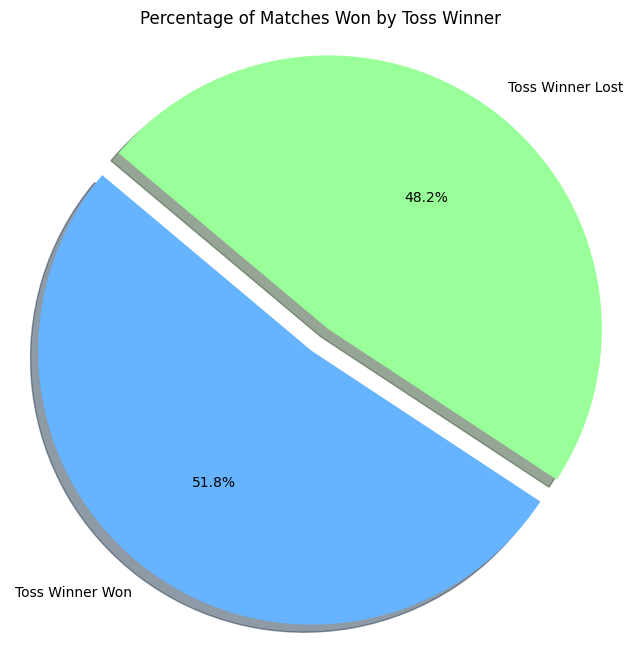

In [ ]:
import matplotlib.pyplot as plt

# Calculate the percentage
percentage_toss_winner_won = (toss_winner_won_match / total_matches) * 100
percentage_toss_winner_lost = 100 - percentage_toss_winner_won

# Data for the pie chart
labels = ['Toss Winner Won', 'Toss Winner Lost']
sizes = [percentage_toss_winner_won, percentage_toss_winner_lost]
colors = ['#66b3ff','#99ff99'] # Example colors
explode = (0.1, 0)  # Explode the 'Toss Winner Won' slice

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Percentage of Matches Won by Toss Winner')
plt.show()

In [ ]:
toss_winner_match_winner = df[df['toss_winner'] == df['match_won_by']]

teams_toss_win_match_win = toss_winner_match_winner.groupby('toss_winner')['match_id'].nunique().sort_values(ascending=False)

print("Teams with most wins after winning the toss:")
print(teams_toss_win_match_win.head(10))

Teams with most wins after winning the toss:
toss_winner
Mumbai Indians                 83
Chennai Super Kings            78
Kolkata Knight Riders          71
Rajasthan Royals               64
Royal Challengers Bangalore    56
Sunrisers Hyderabad            41
Delhi Daredevils               35
Kings XI Punjab                35
Delhi Capitals                 31
Punjab Kings                   21
Name: match_id, dtype: int64


In [ ]:
total_tosses_won = df.groupby('toss_winner')['match_id'].nunique()

winning_percentage_after_toss = (teams_toss_win_match_win / total_tosses_won) * 100

print("Winning percentage of teams after winning the toss:")
display(winning_percentage_after_toss.sort_values(ascending=False).head(10))

Winning percentage of teams after winning the toss:


,match_id
toss_winner,
Rising Pune Supergiant,83.333333
Gujarat Lions,71.428571
Royal Challengers Bengaluru,70.588235
Gujarat Titans,66.666667
Chennai Super Kings,61.417323
Lucknow Super Giants,57.692308
Kolkata Knight Riders,55.038760
Mumbai Indians,54.966887
Punjab Kings,53.846154


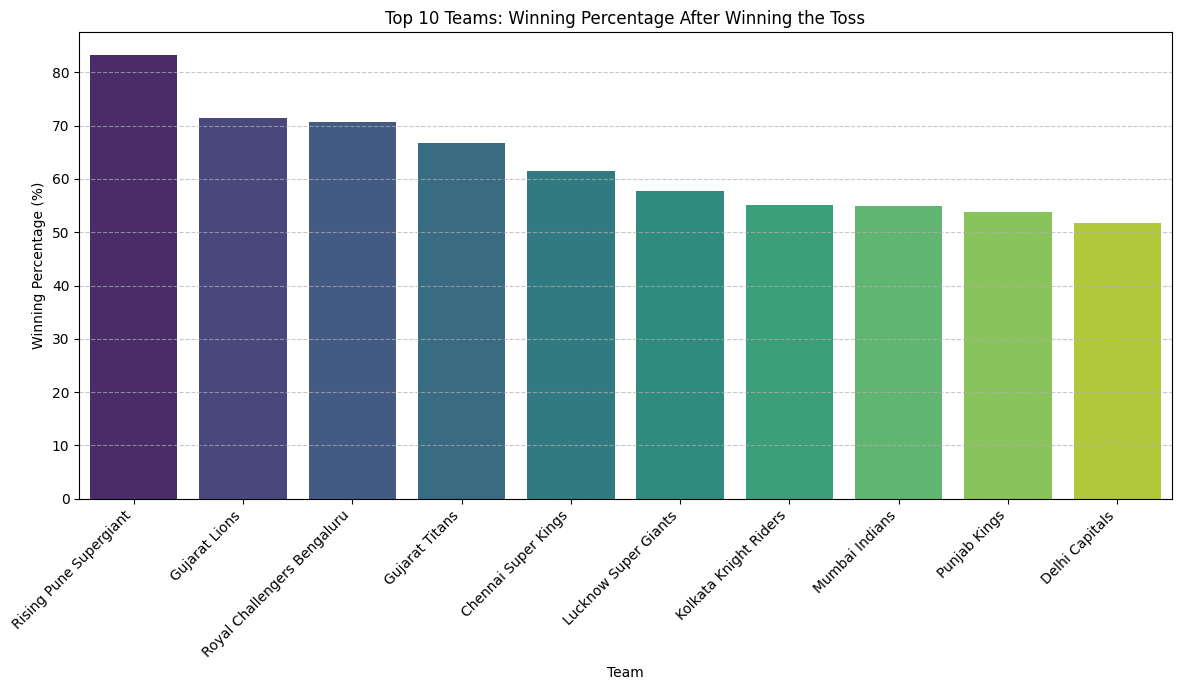

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 teams by winning percentage after winning the toss
top_10_winning_percentage = winning_percentage_after_toss.sort_values(ascending=False).head(10)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_winning_percentage.index, y=top_10_winning_percentage.values, palette='viridis', hue=top_10_winning_percentage.index, legend=False)

plt.xlabel('Team')
plt.ylabel('Winning Percentage (%)')
plt.title('Top 10 Teams: Winning Percentage After Winning the Toss')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

match_data = df.groupby('match_id').first().reset_index()

# Select only the columns necessary for the toss analysis and other related cells
match_data = match_data[['match_id', 'toss_winner', 'toss_decision', 'match_won_by', 'venue']]

# Add a column to indicate if the toss-winning team also won the match
match_data['toss_winner_won_match'] = (match_data['toss_winner'] == match_data['match_won_by'])

toss_decision_outcome = match_data.groupby('toss_decision').agg(
    total_matches=('match_id', 'count'),
    toss_winner_wins=('toss_winner_won_match', 'sum')
).reset_index()

toss_decision_outcome['win_percentage'] = (
    toss_decision_outcome['toss_winner_wins'] / toss_decision_outcome['total_matches']
) * 100

print("Win Percentage by Toss Decision (Toss Winner):")
display(toss_decision_outcome)

Win Percentage by Toss Decision (Toss Winner):


,toss_decision,total_matches,toss_winner_wins,win_percentage
0,bat,397,184,46.347607
1,field,772,422,54.663212


In [ ]:
match_data.head()

,match_id,toss_winner,toss_decision,match_won_by,venue,toss_winner_won_match
0,335982,Royal Challengers Bangalore,field,Kolkata Knight Riders,M Chinnaswamy Stadium,False
1,335983,Chennai Super Kings,bat,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",True
2,335984,Rajasthan Royals,bat,Delhi Daredevils,Feroz Shah Kotla,False
3,335985,Mumbai Indians,bat,Royal Challengers Bangalore,Wankhede Stadium,False
4,335986,Deccan Chargers,bat,Kolkata Knight Riders,Eden Gardens,False


In [ ]:
# Determine if the toss-winning team won the match
match_data['toss_winner_won_match'] = (match_data['toss_winner'] == match_data['match_won_by'])

# Group by venue and toss decision to calculate wins and total matches
toss_outcome_by_venue = match_data.groupby(['venue', 'toss_decision']).agg(
    total_matches=('match_id', 'count'),
    toss_winner_wins=('toss_winner_won_match', 'sum')
).reset_index()

# Calculate win percentage for the toss winner based on their decision
toss_outcome_by_venue['win_percentage'] = (
    toss_outcome_by_venue['toss_winner_wins'] / toss_outcome_by_venue['total_matches']
) * 100

# Filter out venues with very few matches to ensure meaningful statistics for the heatmap
min_matches_for_heatmap = 10  # Set a threshold for minimum total matches at a venue
filtered_toss_outcome_by_venue = toss_outcome_by_venue.groupby('venue').filter(
    lambda x: x['total_matches'].sum() >= min_matches_for_heatmap
)

# Pivot the table for the heatmap
heatmap_data = filtered_toss_outcome_by_venue.pivot_table(
    index='venue',
    columns='toss_decision',
    values='win_percentage'
).fillna(0) # Fill NaN with 0 if a venue doesn't have both 'bat' and 'field' decisions

# Sort by overall win percentage (e.g., average of bat/field win percentages) for better visualization
heatmap_data['overall_win_percentage'] = heatmap_data.mean(axis=1)
heatmap_data = heatmap_data.sort_values(by='overall_win_percentage', ascending=False).drop(columns='overall_win_percentage')

# Display the prepared data for the heatmap
print("Data for Heatmap (Win Percentage by Venue and Toss Decision):")
display(heatmap_data.head())

Data for Heatmap (Win Percentage by Venue and Toss Decision):


toss_decision,bat,field
venue,,
Punjab Cricket Association IS Bindra Stadium,100.000000,66.666667
M.Chinnaswamy Stadium,100.000000,53.846154
"Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",66.666667,70.588235
SuperSport Park,50.000000,83.333333
"Sawai Mansingh Stadium, Jaipur",62.500000,66.666667


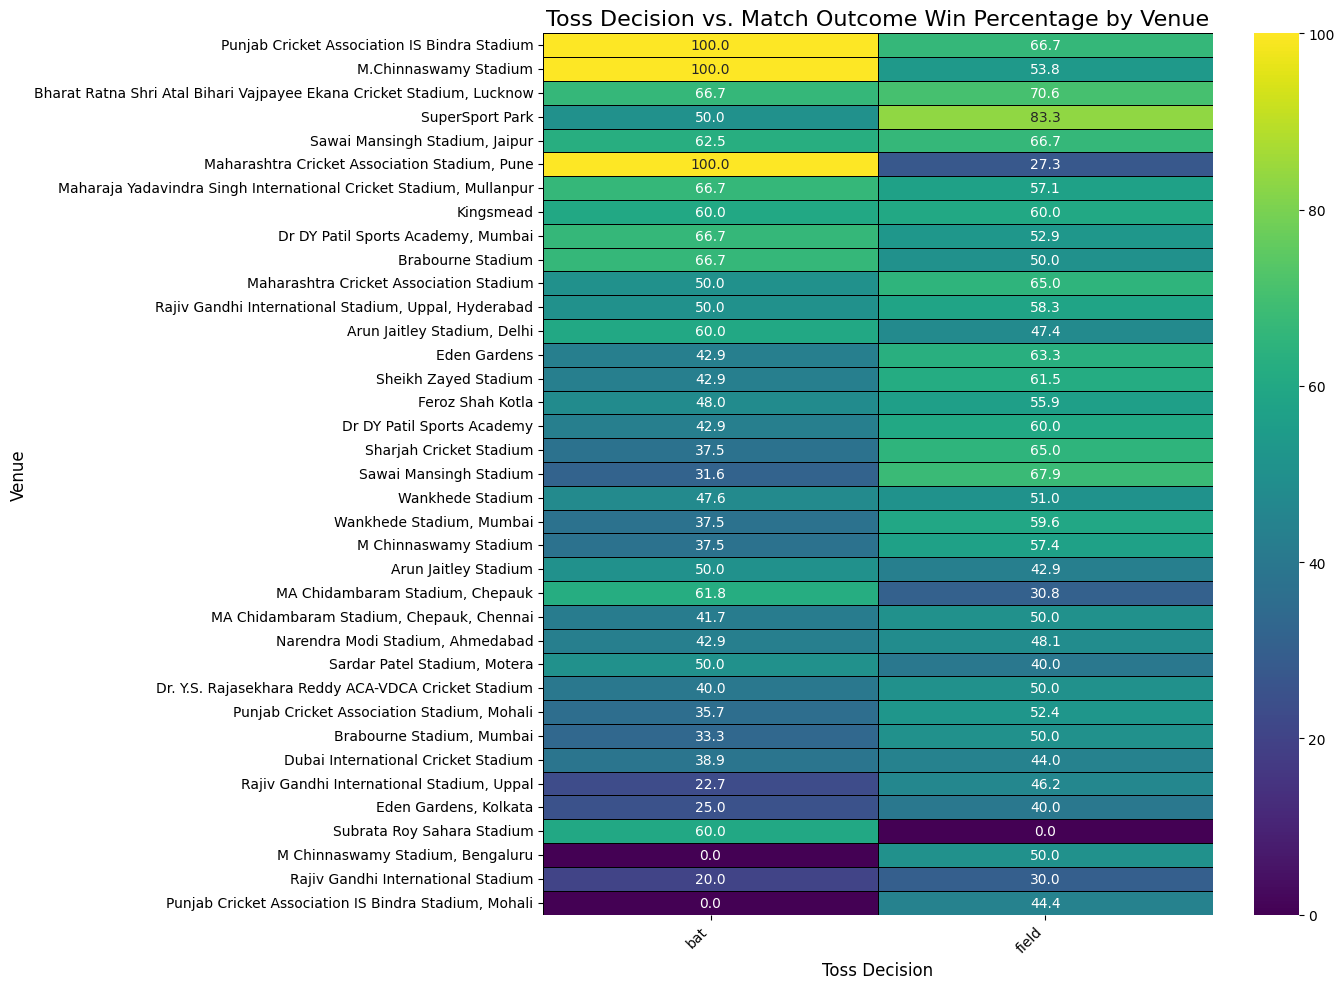

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_data,
    annot=True, # Show the percentage values on the heatmap
    fmt=".1f",  # Format annotations to one decimal place
    cmap="viridis", # Choose a color map
    linewidths=.5, # Add lines between cells
    linecolor='black'
)

plt.title('Toss Decision vs. Match Outcome Win Percentage by Venue', fontsize=16)
plt.xlabel('Toss Decision', fontsize=12)
plt.ylabel('Venue', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Problem Statement: Who are the most effective "Powerplay" batters, and how do they balance aggression (Strike Rate) with consistency (Batting Average)?

In [ ]:
import numpy as np

# ── Batter Career Stats (valid balls only) ────────────────────────────────────
bat_df = df[df['valid_ball'] == 1].copy()

batter_match = bat_df.groupby(['match_id','batter']).agg(
    runs  = ('runs_batter','sum'),
    balls = ('valid_ball','sum'),
    fours = ('runs_batter', lambda x: (x == 4).sum()),
    sixes = ('runs_batter', lambda x: (x == 6).sum()),
).reset_index()
batter_match['sr'] = (batter_match['runs'] / batter_match['balls'].replace(0, np.nan) * 100).round(2)

career = batter_match.groupby('batter').agg(
    innings    = ('match_id','nunique'),
    total_runs = ('runs','sum'),
    total_balls= ('balls','sum'),
    total_4s   = ('fours','sum'),
    total_6s   = ('sixes','sum'),
    avg_score  = ('runs','mean'),
    best_score = ('runs','max'),
).reset_index()
career['career_sr']     = (career['total_runs'] / career['total_balls'].replace(0, np.nan) * 100).round(2)
career['boundary_pct']  = (
    (career['total_4s']*4 + career['total_6s']*6) /
    career['total_runs'].replace(0, np.nan) * 100
).round(2)
career = career[career['innings'] >= 5].sort_values('total_runs', ascending=False)

print("Top 10 Run Scorers (min 5 innings):")
display(career.head(10)[['batter','innings','total_runs','avg_score','career_sr','total_4s','total_6s','best_score']])

Top 10 Run Scorers (min 5 innings):


,batter,innings,total_runs,avg_score,career_sr,total_4s,total_6s,best_score
674,V Kohli,258,8729,33.833333,133.74,783,294,113
514,RG Sharma,266,7092,26.661654,132.59,642,307,109
550,S Dhawan,218,6692,30.697248,127.08,758,151,106
155,DA Warner,180,6448,35.822222,139.84,652,231,126
584,SK Raina,198,5489,27.722222,136.95,504,201,100
400,MS Dhoni,241,5409,22.443983,137.46,375,261,79
304,KL Rahul,134,5166,38.552239,137.17,451,206,132
51,AM Rahane,185,5028,27.178378,125.57,510,129,105
31,AB de Villiers,166,4969,29.933735,151.13,393,242,132
538,RV Uthappa,195,4929,25.276923,130.57,478,182,88


In [ ]:
# Filter the dataset for Powerplay overs (1 to 6)
powerplay_df = df[df['over'].between(1, 6)].copy()

print(f"Original DataFrame shape: {df.shape}")
print(f"Powerplay DataFrame shape: {powerplay_df.shape}")

Original DataFrame shape: (278954, 65)
Powerplay DataFrame shape: (87179, 65)


In [ ]:
powerplay_bat_stats = powerplay_df[powerplay_df['valid_ball'] == 1].groupby('batter').agg(
    runs_scored=('runs_batter', 'sum'),
    balls_faced=('valid_ball', 'sum')
).reset_index()

# Calculate dismissals for each batter in the powerplay
dismissals = powerplay_df[powerplay_df['player_out'].notna()].groupby('player_out').size().reset_index(name='times_dismissed')
dismissals.rename(columns={'player_out': 'batter'}, inplace=True)

# Merge dismissals with batter stats
powerplay_bat_stats = pd.merge(powerplay_bat_stats, dismissals, on='batter', how='left').fillna(0)

# Calculate Strike Rate
powerplay_bat_stats['strike_rate'] = (powerplay_bat_stats['runs_scored'] / powerplay_bat_stats['balls_faced'].replace(0, np.nan)) * 100

# Calculate Average (handle cases where times_dismissed is 0 to avoid division by zero)
powerplay_bat_stats['average'] = powerplay_bat_stats.apply(
    lambda row: row['runs_scored'] / row['times_dismissed'] if row['times_dismissed'] > 0 else row['runs_scored'],
    axis=1
)

# Filter out batters with very few balls faced to ensure meaningful stats
min_balls_faced_powerplay = 100
powerplay_bat_stats = powerplay_bat_stats[powerplay_bat_stats['balls_faced'] >= min_balls_faced_powerplay]

print(f"Top 10 Powerplay Batters (min {min_balls_faced_powerplay} balls faced):")
display(powerplay_bat_stats.sort_values(by='runs_scored', ascending=False).head(10).round(2))

Top 10 Powerplay Batters (min 100 balls faced):


,batter,runs_scored,balls_faced,times_dismissed,strike_rate,average
294,S Dhawan,3275,2618,98.0,125.10,33.42
84,DA Warner,3120,2126,62.0,146.75,50.32
366,V Kohli,3104,2529,72.0,122.74,43.11
31,AM Rahane,2505,1933,72.0,129.59,34.79
275,RG Sharma,2374,1869,83.0,127.02,28.60
110,F du Plessis,2350,1624,58.0,144.70,40.52
74,CH Gayle,2248,1554,65.0,144.66,34.58
113,G Gambhir,2211,1753,70.0,126.13,31.59
163,KL Rahul,2126,1620,36.0,131.23,59.06
287,RV Uthappa,2066,1606,62.0,128.64,33.32


In [ ]:
print("Top 10 Powerplay Batters by Strike Rate:")
display(powerplay_bat_stats.sort_values(by='strike_rate', ascending=False).head(10).round(2))

print("\nTop 10 Powerplay Batters by Average:")
display(powerplay_bat_stats.sort_values(by='average', ascending=False).head(10).round(2))

Top 10 Powerplay Batters by Strike Rate:


,batter,runs_scored,balls_faced,times_dismissed,strike_rate,average
134,J Fraser-McGurk,260,105,7.0,247.62,37.14
370,V Suryavanshi,291,127,5.0,229.13,58.20
257,Priyansh Arya,327,158,16.0,206.96,20.44
5,A Mhatre,259,129,8.0,200.78,32.38
358,TM Head,736,384,15.0,191.67,49.07
41,Abhishek Sharma,1127,601,27.0,187.52,41.74
248,PD Salt,712,383,15.0,185.90,47.47
322,SP Narine,1047,595,51.0,175.97,20.53
229,N Pooran,265,160,8.0,165.62,33.12
272,RD Rickelton,327,200,10.0,163.50,32.70



Top 10 Powerplay Batters by Average:


,batter,runs_scored,balls_faced,times_dismissed,strike_rate,average
194,MC Henriques,246,201,3.0,122.39,82.00
9,A Symonds,137,131,2.0,104.58,68.50
55,B Sai Sudharsan,747,529,11.0,141.21,67.91
165,KP Pietersen,445,337,7.0,132.05,63.57
302,SA Yadav,1102,802,18.0,137.41,61.22
72,CA Lynn,711,460,12.0,154.57,59.25
163,KL Rahul,2126,1620,36.0,131.23,59.06
370,V Suryavanshi,291,127,5.0,229.13,58.20
125,HM Amla,230,177,4.0,129.94,57.50
91,DJ Hussey,167,161,3.0,103.73,55.67


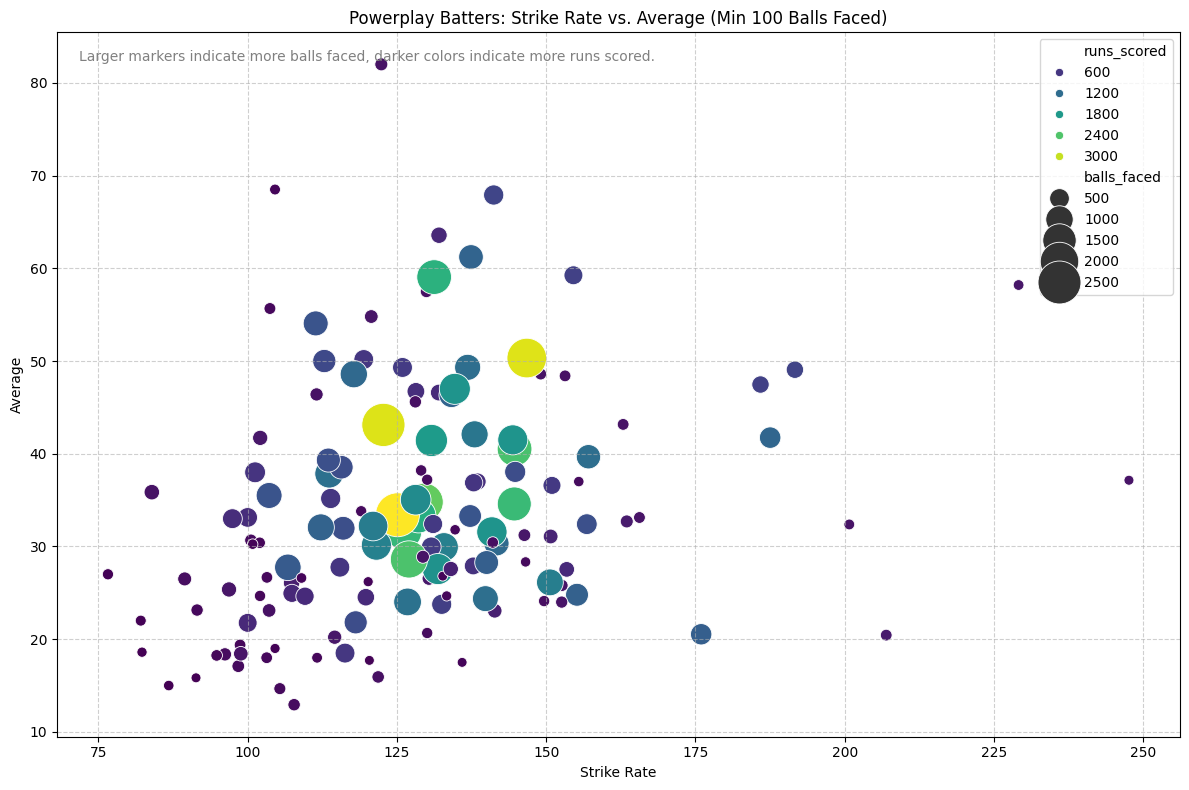

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='strike_rate',
    y='average',
    data=powerplay_bat_stats,
    hue='runs_scored',
    size='balls_faced',
    sizes=(50, 1000),
    palette='viridis',
    legend='brief'
)

plt.title('Powerplay Batters: Strike Rate vs. Average (Min 100 Balls Faced)')
plt.xlabel('Strike Rate')
plt.ylabel('Average')
plt.grid(True, linestyle='--', alpha=0.6)
plt.annotate('Larger markers indicate more balls faced, darker colors indicate more runs scored.',
             xy=(0.02, 0.96), xycoords='axes fraction', fontsize=10, color='gray')
plt.tight_layout()
plt.show()

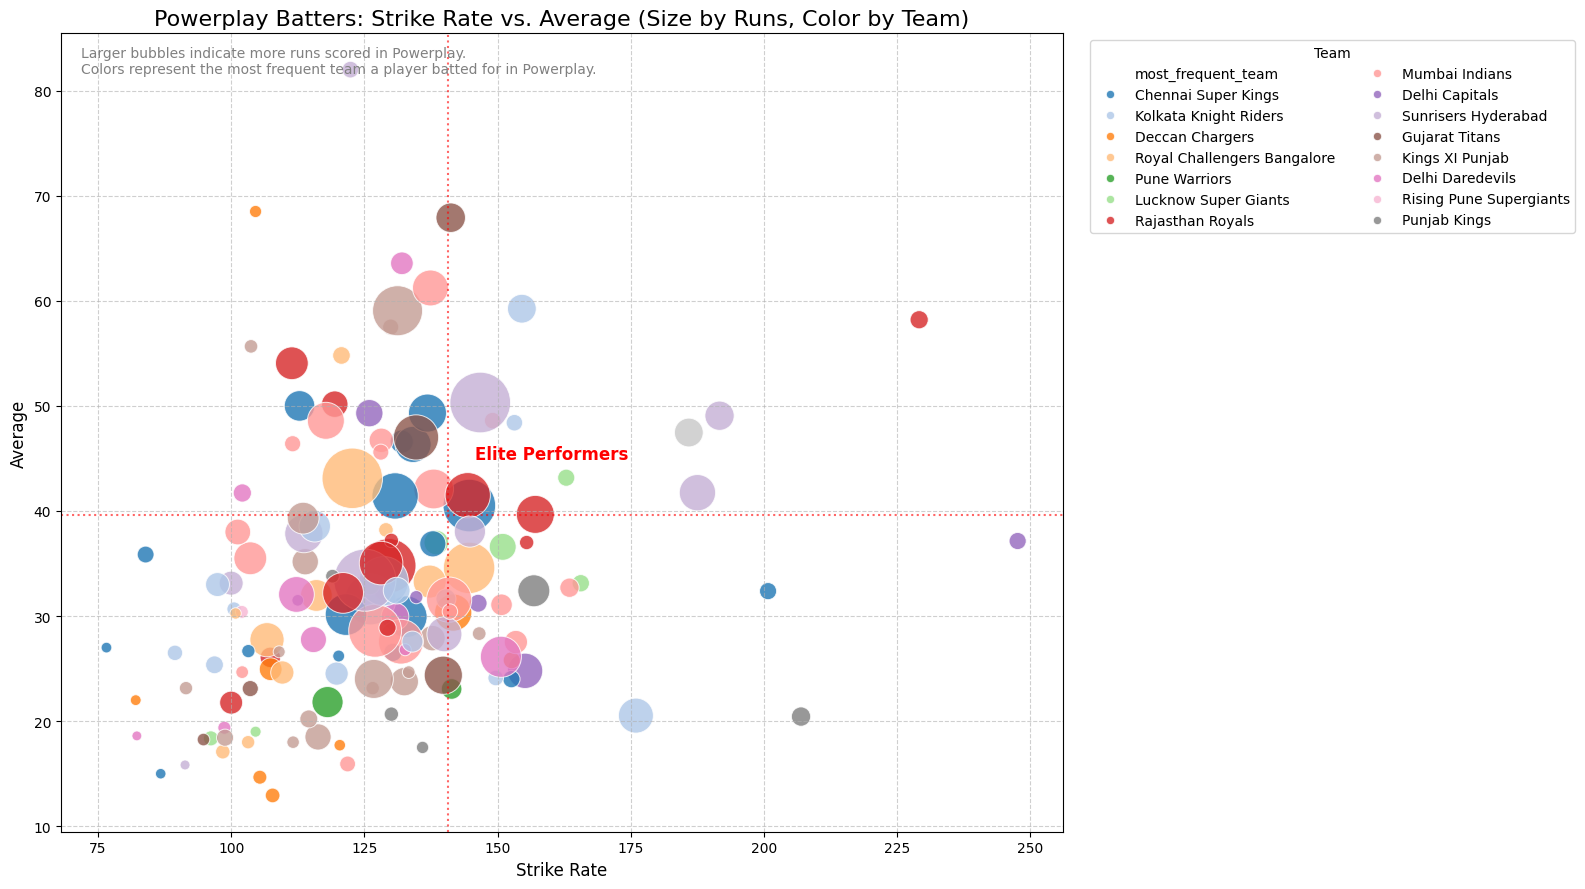

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the most frequent batting team for each batter within the powerplay data
# This handles players who might have played for multiple teams over their career.
most_frequent_team_powerplay = powerplay_df.groupby('batter')['batting_team'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'
).reset_index(name='most_frequent_team')

# Merge this team information into powerplay_bat_stats
powerplay_bat_stats_with_team = pd.merge(
    powerplay_bat_stats,
    most_frequent_team_powerplay,
    on='batter',
    how='left'
)

# Ensure 'runs_scored' is numeric for sizing
powerplay_bat_stats_with_team['runs_scored'] = pd.to_numeric(powerplay_bat_stats_with_team['runs_scored'])

plt.figure(figsize=(16, 9)) # Increased figure width
ax = sns.scatterplot(
    x='strike_rate',
    y='average',
    data=powerplay_bat_stats_with_team,
    hue='most_frequent_team', # Color-code by the most frequent team
    size='runs_scored',       # Size of bubbles by total runs scored in powerplay
    sizes=(50, 2000),         # Adjust size range for better visualization
    palette='tab20',          # Use a palette that can distinguish many teams
    legend=True,             # Disable automatic legend creation by seaborn here
    alpha=0.8
)

plt.title('Powerplay Batters: Strike Rate vs. Average (Size by Runs, Color by Team)', fontsize=16)
plt.xlabel('Strike Rate', fontsize=12)
plt.ylabel('Average', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Add annotation for context
plt.annotate(
    'Larger bubbles indicate more runs scored in Powerplay. \nColors represent the most frequent team a player batted for in Powerplay.',
    xy=(0.02, 0.95), xycoords='axes fraction', fontsize=10, color='gray'
)

# Highlight the top-right quadrant for elite performers
plt.axvline(x=powerplay_bat_stats_with_team['strike_rate'].quantile(0.75), color='red', linestyle=':', linewidth=1.5, alpha=0.6)
plt.axhline(y=powerplay_bat_stats_with_team['average'].quantile(0.75), color='red', linestyle=':', linewidth=1.5, alpha=0.6)
plt.text(powerplay_bat_stats_with_team['strike_rate'].quantile(0.75) + 5,
         powerplay_bat_stats_with_team['average'].quantile(0.75) + 5,
         'Elite Performers',
         color='red', fontsize=12, ha='left', va='bottom', weight='bold')

# Get handles and labels for the legend explicitly
handles, labels = ax.get_legend_handles_labels()

# Manually create the legend for 'hue' (most_frequent_team)
# Ensure we only get the legend for the teams, not for the sizes.
# The first `len(set(labels))` items will be for the `hue` variable.
num_hue_categories = len(powerplay_bat_stats_with_team['most_frequent_team'].unique())
ax.legend(handles[:num_hue_categories], labels[:num_hue_categories],
          bbox_to_anchor=(1.02, 1), loc='upper left', title='Team', ncol=2)

plt.tight_layout()
plt.show()

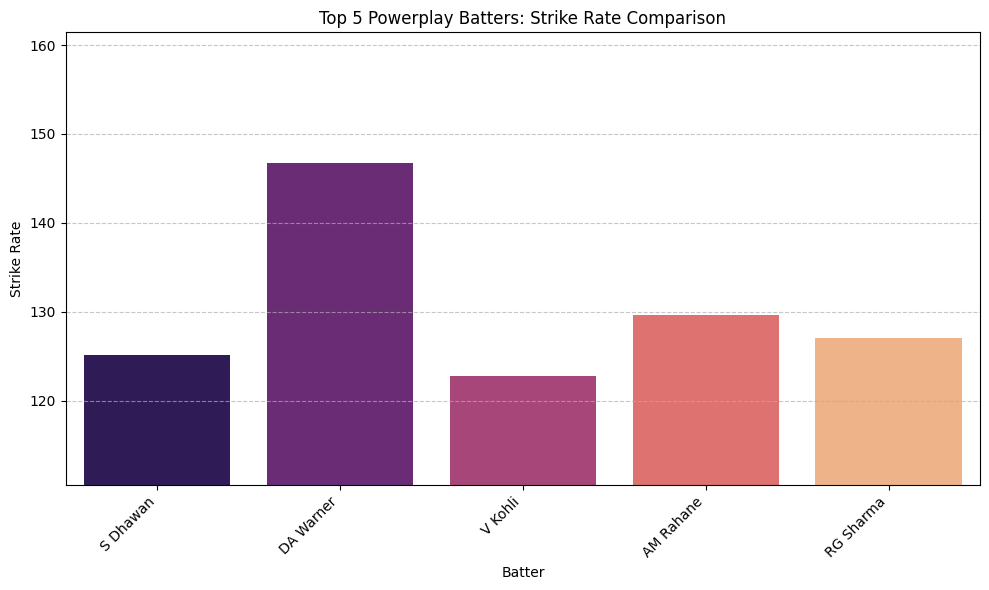

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 5 run scorers in Powerplay
top_5_powerplay_batters = powerplay_bat_stats.sort_values(by='runs_scored', ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='batter',
    y='strike_rate',
    data=top_5_powerplay_batters,
    palette='magma',
    hue='batter',
    legend=False
)

plt.title('Top 5 Powerplay Batters: Strike Rate Comparison')
plt.xlabel('Batter')
plt.ylabel('Strike Rate')
plt.ylim(min(top_5_powerplay_batters['strike_rate']) * 0.9, max(top_5_powerplay_batters['strike_rate']) * 1.1) # Adjust y-axis for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Problem Statement: How does the run-scoring rate change across the three phases of a T20 innings (Powerplay, Middle Overs, Death Overs), and which bowlers are the most economical in the Death Overs?

In [ ]:
def assign_match_phase(over):
    if 1 <= over <= 6:
        return 'Powerplay'
    elif 7 <= over <= 15:
        return 'Middle'
    elif 16 <= over <= 20:
        return 'Death'
    else:
        return 'Other'

df['Match_Phase'] = df['over'].apply(assign_match_phase)

print("New 'Match_Phase' column created. Displaying value counts:")
display(df['Match_Phase'].value_counts())
display(df.head())

New 'Match_Phase' column created. Displaying value counts:


,count
Match_Phase,
Middle,127481
Powerplay,87179
Death,49589
Other,14705


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out,Match_Phase
0,141607,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False,Other
1,141608,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False,Other
2,141609,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False,Other
3,141610,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,0,NaN,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False,Other
4,141611,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,0,NaN,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False,Other


In [ ]:
# Calculate total runs and total overs (each ball is approx 1/6th of an over) for each match phase
phase_stats = df.groupby('Match_Phase').agg(
    total_runs=('runs_total', 'sum'),
    total_balls=('ball', 'count')  # Counting total balls bowled in each phase
).reset_index()

# Convert total balls to total overs by dividing by 6
phase_stats['total_overs'] = phase_stats['total_balls'] / 6

# Calculate run-scoring rate (runs per over)
phase_stats['run_rate'] = (phase_stats['total_runs'] / phase_stats['total_overs']).round(2)

print("Run-scoring rate across different match phases:")
display(phase_stats.sort_values(by='run_rate', ascending=False))

Run-scoring rate across different match phases:


,Match_Phase,total_runs,total_balls,total_overs,run_rate
0,Death,80565,49589,8264.833333,9.75
1,Middle,167378,127481,21246.833333,7.88
3,Powerplay,113923,87179,14529.833333,7.84
2,Other,14603,14705,2450.833333,5.96


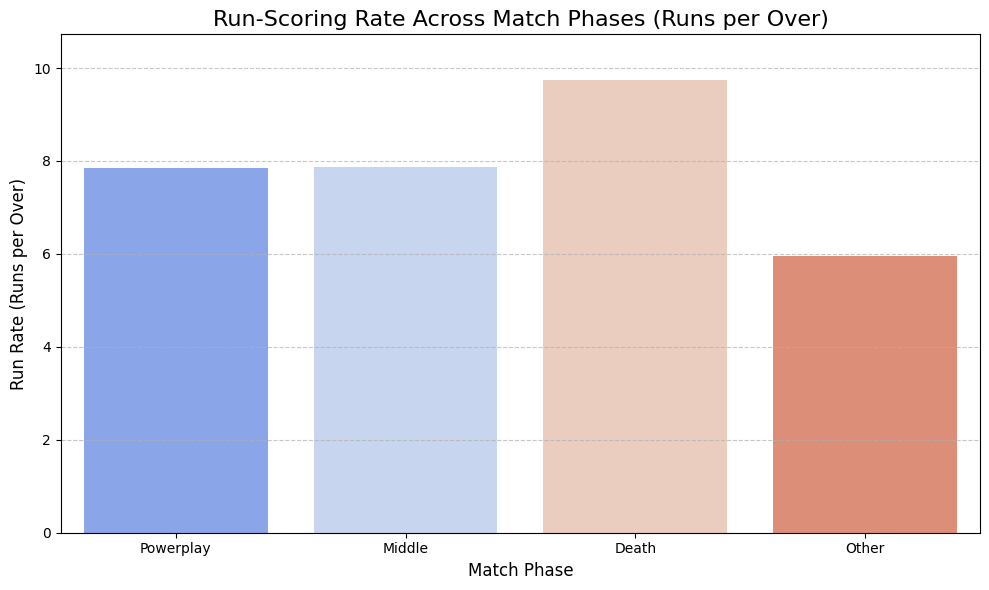

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort phases for logical plotting order if 'Other' is present, otherwise just plot
ordered_phases = ['Powerplay', 'Middle', 'Death', 'Other']
phase_stats['Match_Phase'] = pd.Categorical(phase_stats['Match_Phase'], categories=ordered_phases, ordered=True)
phase_stats = phase_stats.sort_values('Match_Phase')

plt.figure(figsize=(10, 6))
sns.barplot(x='Match_Phase', y='run_rate', data=phase_stats, palette='coolwarm', hue='Match_Phase', legend=False)

plt.title('Run-Scoring Rate Across Match Phases (Runs per Over)', fontsize=16)
plt.xlabel('Match Phase', fontsize=12)
plt.ylabel('Run Rate (Runs per Over)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, phase_stats['run_rate'].max() * 1.1) # Set y-limit for better visualization
plt.tight_layout()
plt.show()

In [ ]:
# Filter for Death Overs (overs 16-20) and valid balls
death_overs_df = df[(df['Match_Phase'] == 'Death') & (df['valid_ball'] == 1)].copy()

# Group by bowler to calculate total runs conceded and total balls bowled
death_overs_bowler_stats = death_overs_df.groupby('bowler').agg(
    runs_conceded=('runs_total', 'sum'),
    balls_bowled=('ball', 'count')
).reset_index()

# Filter out bowlers with very few balls bowled in death overs to get meaningful economy
min_balls_death_overs = 60 # Equivalent to 10 overs
death_overs_bowler_stats = death_overs_bowler_stats[
    death_overs_bowler_stats['balls_bowled'] >= min_balls_death_overs
]

# Calculate Economy Rate (runs conceded per over)
death_overs_bowler_stats['economy_rate'] = (
    death_overs_bowler_stats['runs_conceded'] / (death_overs_bowler_stats['balls_bowled'] / 6)
).round(2)

print(f"Top 10 Most Economical Bowlers in Death Overs (min {min_balls_death_overs} balls bowled):")
display(death_overs_bowler_stats.sort_values(by='economy_rate', ascending=True).head(10))

Top 10 Most Economical Bowlers in Death Overs (min 60 balls bowled):


,bowler,runs_conceded,balls_bowled,economy_rate
229,M Theekshana,101,90,6.73
392,Sohail Tanvir,108,96,6.75
101,DE Bollinger,261,210,7.46
218,M Ashwin,90,72,7.50
378,SW Tait,161,126,7.67
362,SL Malinga,1176,911,7.75
369,SP Narine,990,751,7.91
6,A Kumble,140,106,7.92
428,WD Parnell,252,189,8.00
125,GB Hogg,107,80,8.02


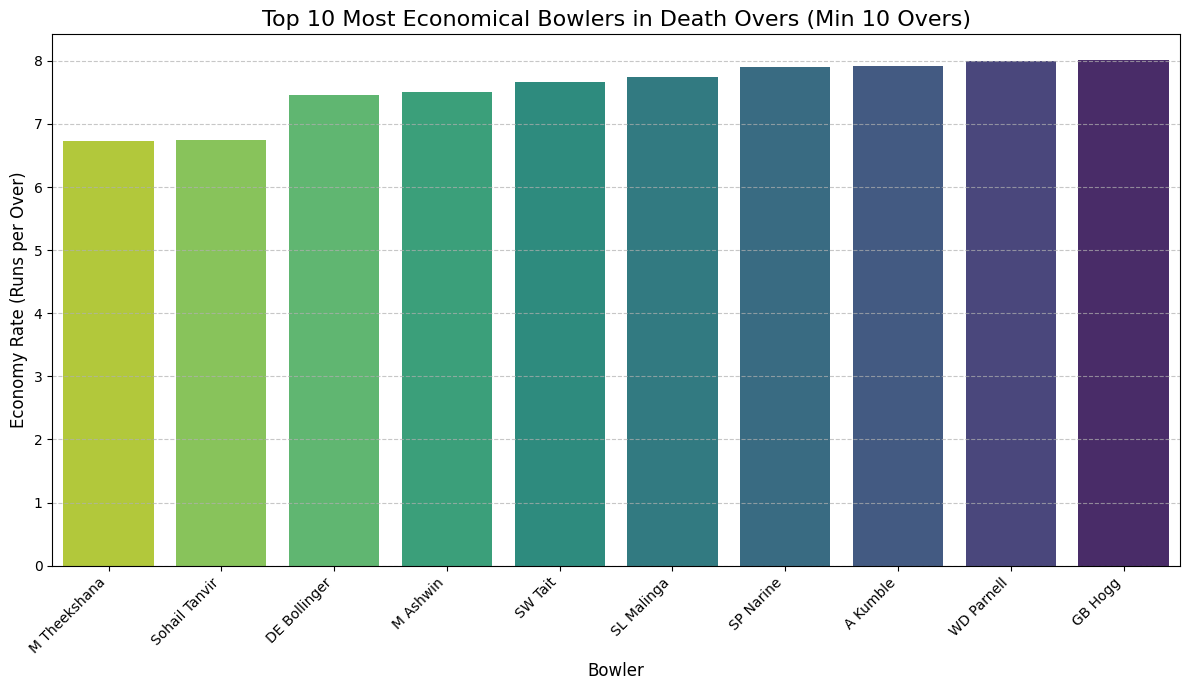

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 most economical bowlers
top_10_economical_bowlers = death_overs_bowler_stats.sort_values(by='economy_rate', ascending=True).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='bowler',
    y='economy_rate',
    data=top_10_economical_bowlers,
    palette='viridis_r', # Reverse viridis to show lower economy as darker
    hue='bowler',
    legend=False
)

plt.title('Top 10 Most Economical Bowlers in Death Overs (Min 10 Overs)', fontsize=16)
plt.xlabel('Bowler', fontsize=12)
plt.ylabel('Economy Rate (Runs per Over)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

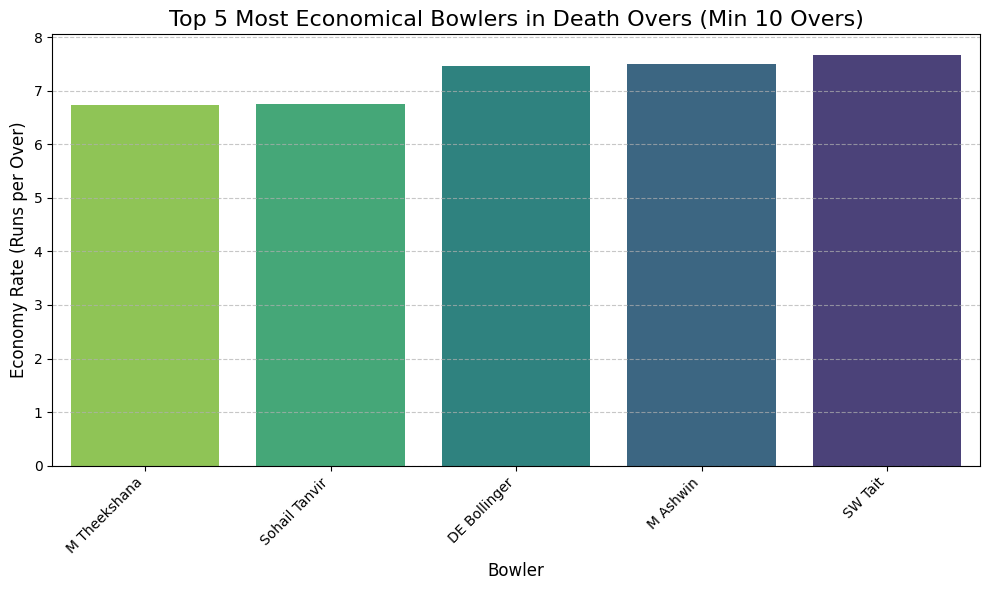

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 5 most economical bowlers from the already sorted list
top_5_economical_bowlers = death_overs_bowler_stats.sort_values(by='economy_rate', ascending=True).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='bowler',
    y='economy_rate',
    data=top_5_economical_bowlers,
    palette='viridis_r', # Reverse viridis to show lower economy as darker
    hue='bowler',
    legend=False
)

plt.title('Top 5 Most Economical Bowlers in Death Overs (Min 10 Overs)', fontsize=16)
plt.xlabel('Bowler', fontsize=12)
plt.ylabel('Economy Rate (Runs per Over)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The Problem: Did the Impact Player rule actually increase a chasing team's win probability, or did it just artificially inflate totals for both sides?

In [ ]:
# Split data into Pre-Impact (2008-2022) and Impact Era (2023-2026)
pre_impact_df = df[(df['year'] >= 2008) & (df['year'] <= 2022)].copy()
impact_era_df = df[(df['year'] >= 2023) & (df['year'] <= 2026)].copy()

print(f"Shape of Pre-Impact Era DataFrame (2008-2022): {pre_impact_df.shape}")
print(f"Shape of Impact Era DataFrame (2023-2025): {impact_era_df.shape}")

Shape of Pre-Impact Era DataFrame (2008-2022): (221948, 66)
Shape of Impact Era DataFrame (2023-2025): (57006, 66)


In [ ]:
# Calculate total runs per match for Pre-Impact Era
pre_impact_total_runs_per_match = pre_impact_df.groupby('match_id')['runs_total'].sum()

# Calculate average total runs per match for Pre-Impact Era
avg_pre_impact_total_runs = pre_impact_total_runs_per_match.mean()

# Calculate total runs per match for Impact Era
impact_era_total_runs_per_match = impact_era_df.groupby('match_id')['runs_total'].sum()

# Calculate average total runs per match for Impact Era
avg_impact_era_total_runs = impact_era_total_runs_per_match.mean()

print(f"Average total runs per match in Pre-Impact Era (2008-2022): {avg_pre_impact_total_runs:.2f}")
print(f"Average total runs per match in Impact Era (2023-2025): {avg_impact_era_total_runs:.2f}")

Average total runs per match in Pre-Impact Era (2008-2022): 311.94
Average total runs per match in Impact Era (2023-2025): 361.77


In [ ]:
# Calculate total runs per match along with the year
match_totals_by_year = df.groupby(['match_id', 'year'])['runs_total'].sum().reset_index()

# Identify matches with 200+ totals
high_scoring_matches = match_totals_by_year[match_totals_by_year['runs_total'] >= 200]

# Calculate the year-over-year frequency of 200+ totals
year_over_year_200_plus_totals = high_scoring_matches['year'].value_counts().sort_index()

print("Year-over-year frequency of matches with 200+ total runs:")
display(year_over_year_200_plus_totals)

Year-over-year frequency of matches with 200+ total runs:


,count
year,
2008,57
2009,54
2010,57
2011,66
2012,72
2013,71
2014,57
2015,54
2016,57


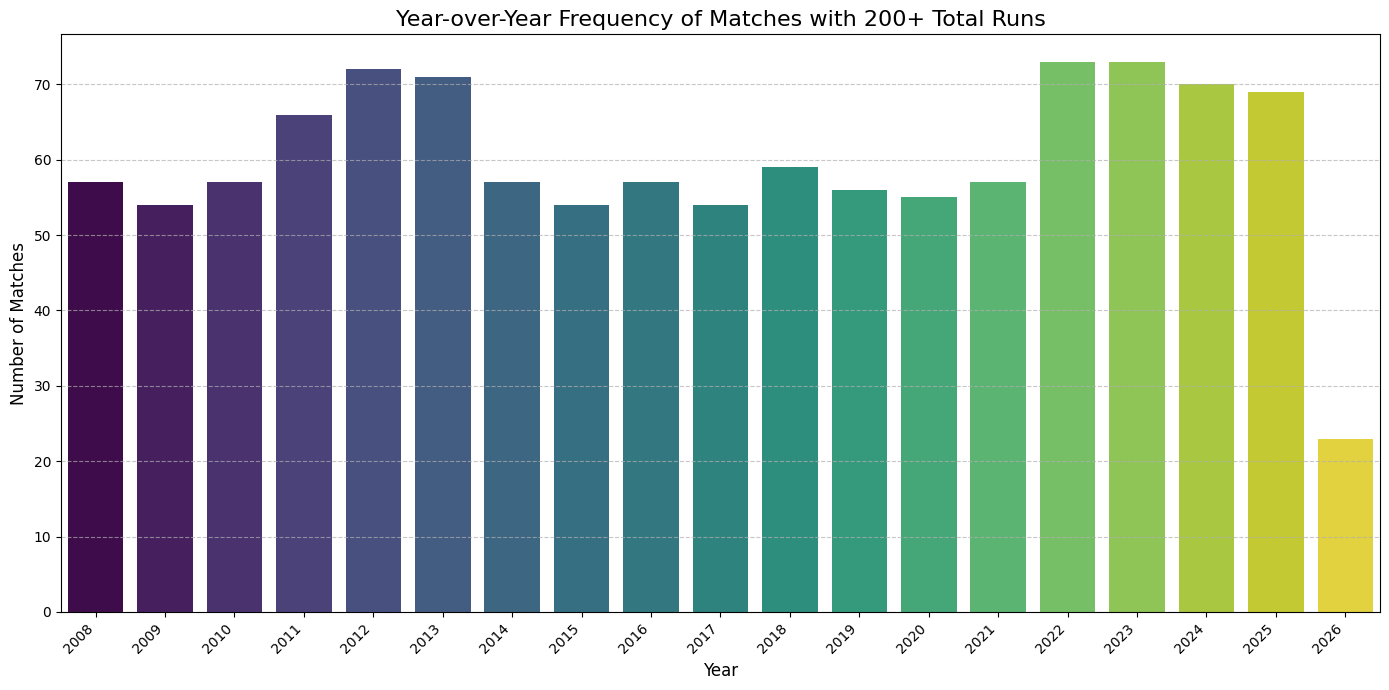

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.barplot(x=year_over_year_200_plus_totals.index, y=year_over_year_200_plus_totals.values, palette='viridis', hue=year_over_year_200_plus_totals.index, legend=False)

plt.title('Year-over-Year Frequency of Matches with 200+ Total Runs', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Get batting first team for each match
batting_first_teams = df[df['innings'] == 1].groupby('match_id')['batting_team'].first()

# Get chasing team for each match
chasing_teams = df[df['innings'] == 2].groupby('match_id')['batting_team'].first()

# Get match winner and year for each match
match_level_data = df.groupby('match_id').agg(
    year=('year', 'first'),
    match_won_by=('match_won_by', 'first')
).reset_index()

# Merge the batting first and chasing teams into the match_level_data
match_level_data = pd.merge(match_level_data, batting_first_teams.rename('batting_first_team'), on='match_id', how='left')
match_level_data = pd.merge(match_level_data, chasing_teams.rename('chasing_team'), on='match_id', how='left')

# Define a function to determine if the batting first team or chasing team won
def get_win_type(row):
    if row['match_won_by'] == row['batting_first_team']:
        return 'Batting First Win'
    elif row['match_won_by'] == row['chasing_team']:
        return 'Chasing Win'
    return 'Undetermined' # In case of ties or other unresolved outcomes (should be rare after initial cleaning)

# Apply the function to create a new 'win_type' column
match_level_data['win_type'] = match_level_data.apply(get_win_type, axis=1)

# Display a sample of the match-level data with win type
print("Sample of match-level data with win type:")
display(match_level_data.head())

Sample of match-level data with win type:


,match_id,year,match_won_by,batting_first_team,chasing_team,win_type
0,335982,2008,Kolkata Knight Riders,Kolkata Knight Riders,Royal Challengers Bangalore,Batting First Win
1,335983,2008,Chennai Super Kings,Chennai Super Kings,Kings XI Punjab,Batting First Win
2,335984,2008,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,Chasing Win
3,335985,2008,Royal Challengers Bangalore,Mumbai Indians,Royal Challengers Bangalore,Chasing Win
4,335986,2008,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders,Chasing Win


In [ ]:
# Split match_level_data into Pre-Impact and Impact Eras
pre_impact_match_summary = match_level_data[(match_level_data['year'] >= 2008) & (match_level_data['year'] <= 2022)].copy()
impact_era_match_summary = match_level_data[(match_level_data['year'] >= 2023) & (match_level_data['year'] <= 2026)].copy()

# --- Calculate win percentages for Pre-Impact Era (2008-2022) ---
total_pre_impact_matches = pre_impact_match_summary.shape[0]
bat_first_wins_pre_impact = (pre_impact_match_summary['win_type'] == 'Batting First Win').sum()
chasing_wins_pre_impact = (pre_impact_match_summary['win_type'] == 'Chasing Win').sum()

# Calculate percentages, handling division by zero if no matches in an era (though unlikely here)
bat_first_win_percent_pre_impact = (bat_first_wins_pre_impact / total_pre_impact_matches) * 100 if total_pre_impact_matches > 0 else 0
chasing_win_percent_pre_impact = (chasing_wins_pre_impact / total_pre_impact_matches) * 100 if total_pre_impact_matches > 0 else 0

print("\nPre-Impact Era (2008-2022) Win Percentages:")
print(f"  Batting First Win Percentage: {bat_first_win_percent_pre_impact:.2f}%")
print(f"  Chasing Win Percentage: {chasing_win_percent_pre_impact:.2f}%")

# --- Calculate win percentages for Impact Era (2023-2026) ---
total_impact_era_matches = impact_era_match_summary.shape[0]
bat_first_wins_impact_era = (impact_era_match_summary['win_type'] == 'Batting First Win').sum()
chasing_wins_impact_era = (impact_era_match_summary['win_type'] == 'Chasing Win').sum()

bat_first_win_percent_impact_era = (bat_first_wins_impact_era / total_impact_era_matches) * 100 if total_impact_era_matches > 0 else 0
chasing_win_percent_impact_era = (chasing_wins_impact_era / total_impact_era_matches) * 100 if total_impact_era_matches > 0 else 0

print("\nImpact Era (2023-2026) Win Percentages:")
print(f"  Batting First Win Percentage: {bat_first_win_percent_impact_era:.2f}%")
print(f"  Chasing Win Percentage: {chasing_win_percent_impact_era:.2f}%")


Pre-Impact Era (2008-2022) Win Percentages:
  Batting First Win Percentage: 44.74%
  Chasing Win Percentage: 55.26%

Impact Era (2023-2026) Win Percentages:
  Batting First Win Percentage: 49.37%
  Chasing Win Percentage: 50.63%


Problem Statement : In the death overs (16-20), is it statistically more valuable to take wickets or simply bowl dot balls?

In [ ]:
death_overs_deliveries_df = df[df['Match_Phase'] == 'Death'].copy()

print("DataFrame for deliveries in Death Overs (16-20) created.")
display(death_overs_deliveries_df.head())

DataFrame for deliveries in Death Overs (16-20) created.


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out,Match_Phase
100,141707,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,16,1,...,2,NaN,NaN,103,56,0,"('BB McCullum', 'DJ Hussey')",NaN,False,Death
101,141708,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,16,2,...,2,NaN,NaN,11,10,0,"('BB McCullum', 'DJ Hussey')",NaN,False,Death
102,141709,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,16,3,...,2,NaN,NaN,12,11,0,"('BB McCullum', 'DJ Hussey')",NaN,False,Death
103,141710,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,16,4,...,2,NaN,NaN,109,57,0,"('BB McCullum', 'DJ Hussey')",NaN,False,Death
104,141711,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,16,5,...,2,NaN,NaN,111,58,0,"('BB McCullum', 'DJ Hussey')",NaN,False,Death


### Bowler Effectiveness in Death Overs

In [ ]:
# Calculate total runs conceded, balls bowled, and wickets taken for each bowler in death overs
bowler_death_stats = death_overs_deliveries_df.groupby('bowler').agg(
    runs_conceded=('runs_total', 'sum'),
    balls_bowled=('ball', 'count'),
    wickets_taken=('wicket_kind', lambda x: x.notna().sum()) # Count non-null wickets
).reset_index()

# Filter for bowlers with at least 30 death overs (30 * 6 = 180 balls) to ensure meaningful statistics
min_balls_for_death_bowlers = 180
bowler_death_stats_filtered = bowler_death_stats[
    bowler_death_stats['balls_bowled'] >= min_balls_for_death_bowlers
].copy()

# Calculate Economy Rate (runs conceded per over)
bowler_death_stats_filtered['economy_rate'] = (
    bowler_death_stats_filtered['runs_conceded'] / (bowler_death_stats_filtered['balls_bowled'] / 6)
).round(2)

# Calculate Bowling Strike Rate (balls per wicket)
# Handle cases where wickets_taken is 0 to avoid division by zero (assign np.inf for such cases)
bowler_death_stats_filtered['strike_rate'] = bowler_death_stats_filtered.apply(
    lambda row: round(row['balls_bowled'] / row['wickets_taken'], 2) if row['wickets_taken'] > 0 else np.inf,
    axis=1
)

print(f"Bowler Stats in Death Overs (Min {min_balls_for_death_bowlers} balls bowled):")
display(bowler_death_stats_filtered.sort_values(by=['economy_rate', 'strike_rate']).head(10))

Bowler Stats in Death Overs (Min 180 balls bowled):


,bowler,runs_conceded,balls_bowled,wickets_taken,economy_rate,strike_rate
101,DE Bollinger,268,216,26,7.44,8.31
362,SL Malinga,1240,959,104,7.76,9.22
369,SP Narine,1015,767,71,7.94,10.80
428,WD Parnell,268,199,20,8.08,9.95
166,JJ Bumrah,1659,1225,95,8.13,12.89
113,DP Nannes,267,193,20,8.30,9.65
205,Kuldeep Yadav,263,188,18,8.39,10.44
84,CH Morris,826,590,59,8.40,10.00
136,Harbhajan Singh,258,184,20,8.41,9.20
330,Rashid Khan,484,345,28,8.42,12.32


### Relationship between Economy Rate and Strike Rate for Death Bowlers

/tmp/ipykernel_485/4209680238.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


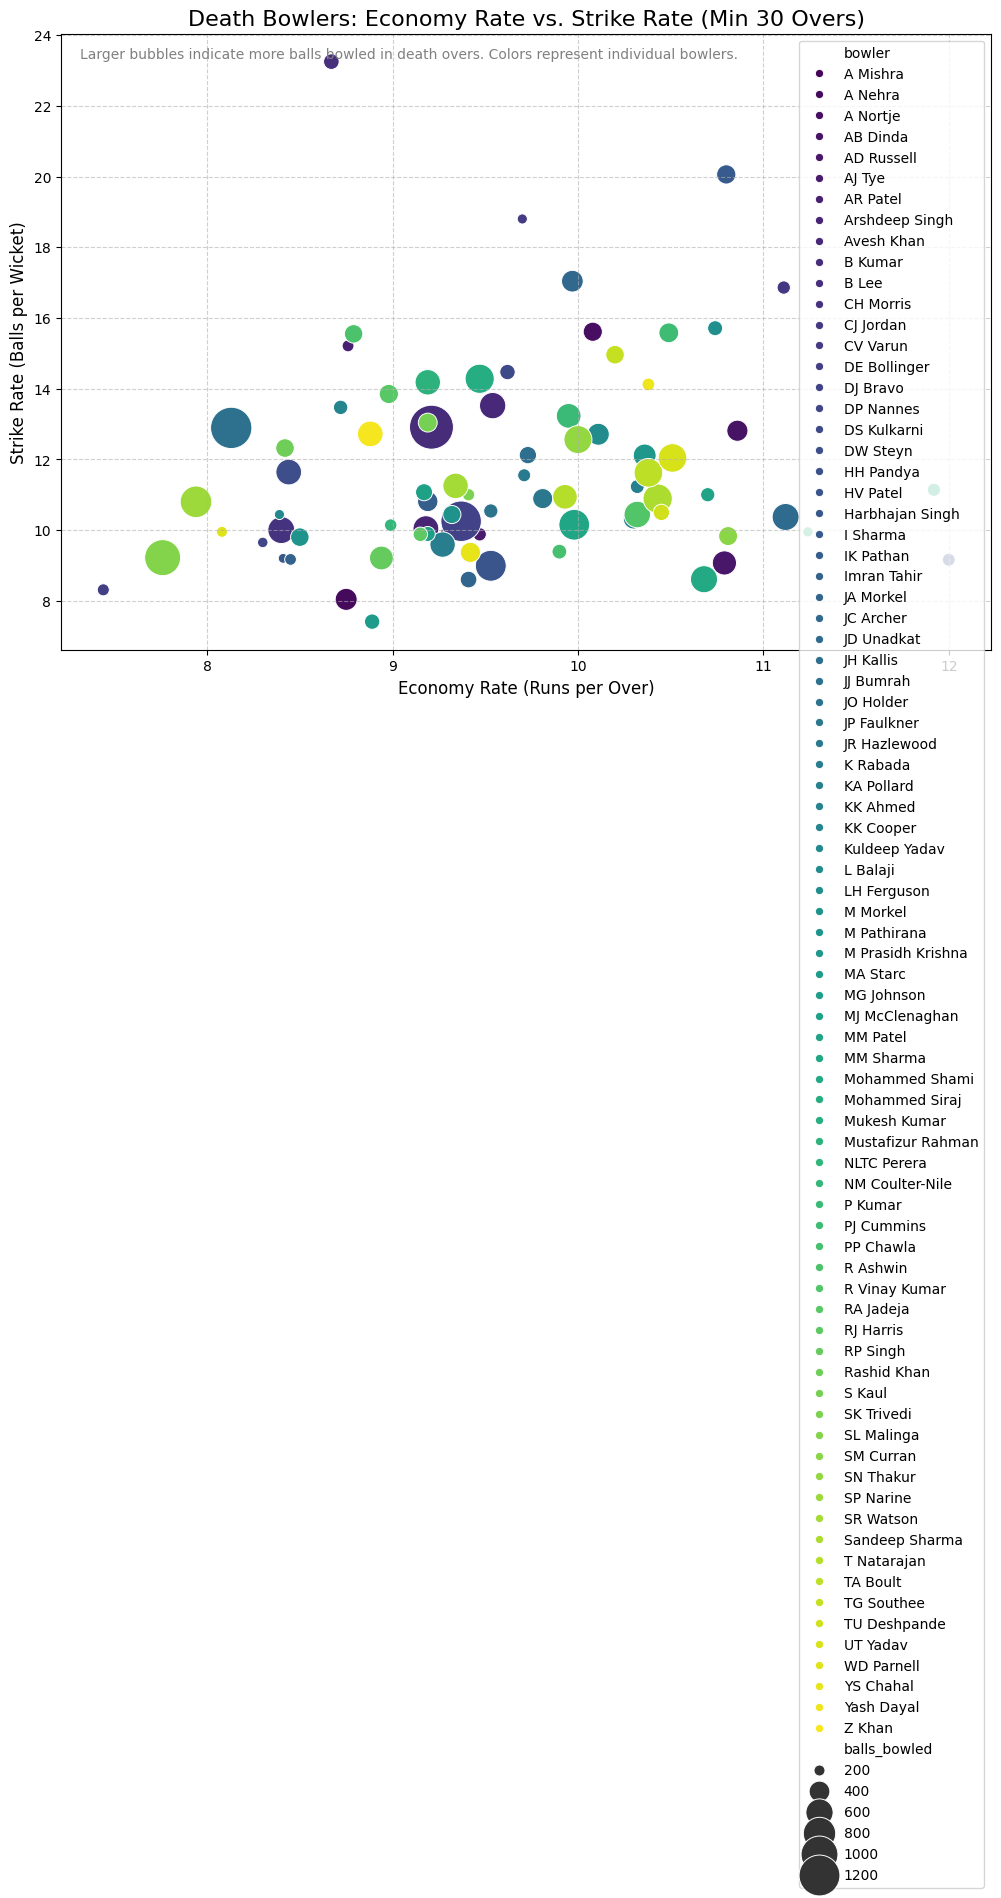

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='economy_rate',
    y='strike_rate',
    data=bowler_death_stats_filtered,
    hue='bowler', # Color points by bowler to distinguish them
    size='balls_bowled', # Size points by number of balls bowled to indicate experience
    sizes=(50, 1000),
    palette='viridis',
    legend='brief' # Show a brief legend
)

plt.title('Death Bowlers: Economy Rate vs. Strike Rate (Min 30 Overs)', fontsize=16)
plt.xlabel('Economy Rate (Runs per Over)', fontsize=12)
plt.ylabel('Strike Rate (Balls per Wicket)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate the plot to explain the size and color
plt.annotate(
    'Larger bubbles indicate more balls bowled in death overs. Colors represent individual bowlers.',
    xy=(0.02, 0.96), xycoords='axes fraction', fontsize=10, color='gray'
)

plt.tight_layout()
plt.show()

### Correlation Analysis: Dot Balls in Death Overs vs. Final Innings Total


Correlation between Dot Balls in Death Overs and Final Innings Total: -0.28


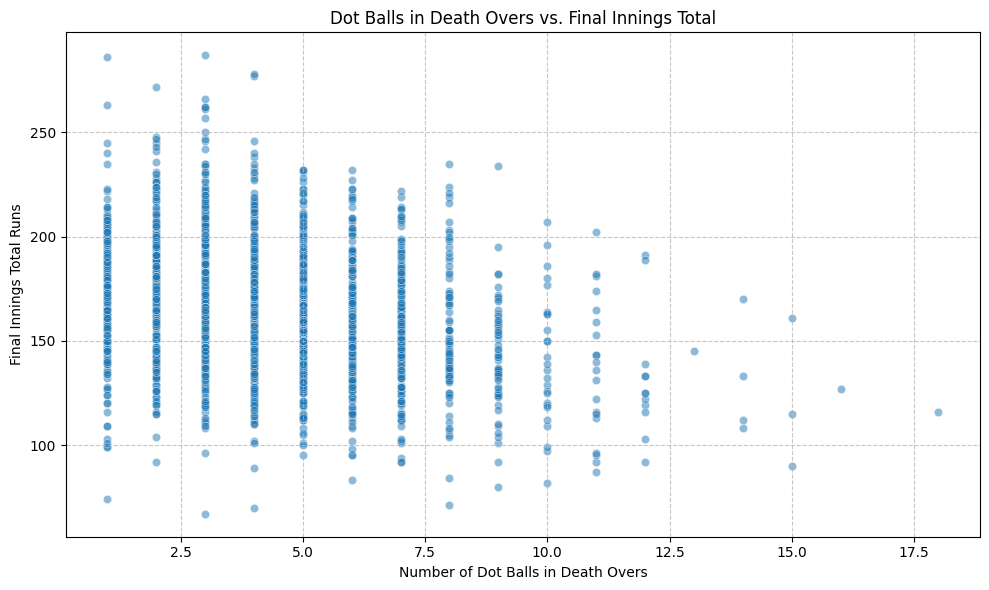

There is a moderate negative correlation, suggesting that more dot balls in death overs are associated with lower innings totals.


In [ ]:
# 1. Get dot balls per innings in death overs
# A dot ball is defined as a valid delivery where 0 runs are scored and no wicket is taken.
innings_death_dot_balls = death_overs_deliveries_df[
    (death_overs_deliveries_df['runs_total'] == 0) & (death_overs_deliveries_df['wicket_kind'].isna())
].groupby(['match_id', 'innings'])['ball'].count().reset_index(name='death_overs_dot_balls')

# 2. Get total runs per innings (final innings total)
innings_total_runs = df.groupby(['match_id', 'innings'])['runs_total'].sum().reset_index(name='innings_final_total')

# 3. Merge these two DataFrames on match_id and innings
correlation_analysis_df = pd.merge(
    innings_death_dot_balls,
    innings_total_runs,
    on=['match_id', 'innings'],
    how='inner'
)

# 4. Calculate the correlation
correlation = correlation_analysis_df['death_overs_dot_balls'].corr(correlation_analysis_df['innings_final_total'])

print(f"\nCorrelation between Dot Balls in Death Overs and Final Innings Total: {correlation:.2f}")

# Visualize the correlation (scatterplot)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='death_overs_dot_balls', y='innings_final_total', data=correlation_analysis_df, alpha=0.5)
plt.title('Dot Balls in Death Overs vs. Final Innings Total')
plt.xlabel('Number of Dot Balls in Death Overs')
plt.ylabel('Final Innings Total Runs')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Interpret the correlation
if correlation > 0.5:
    correlation_interpretation = "There is a strong positive correlation. This might seem counter-intuitive, but it could imply that in innings where more dot balls are bowled in death overs, the batting team might have also faced more deliveries overall, or the pressure of dot balls led to strategic decisions that allowed for higher totals in other phases. Further investigation is needed to fully understand this relationship."
elif correlation < -0.5:
    correlation_interpretation = "There is a strong negative correlation, suggesting that more dot balls in death overs are associated with lower innings totals. This makes intuitive sense as dot balls restrict scoring."
elif correlation > 0.2:
    correlation_interpretation = "There is a moderate positive correlation. This suggests a nuanced relationship where more dot balls in death overs might be associated with slightly higher innings totals under certain conditions, warranting further analysis."
elif correlation < -0.2:
    correlation_interpretation = "There is a moderate negative correlation, suggesting that more dot balls in death overs are associated with lower innings totals."
else:
    correlation_interpretation = "There is a weak or no significant correlation, suggesting that the number of dot balls in death overs does not strongly influence the final innings total directly."

print(correlation_interpretation)

### Death Bowler Performance Comparison: Pre-Impact Era vs. Impact Era

In [ ]:
# 1. Split death_overs_deliveries_df into Pre-Impact and Impact Eras
death_overs_pre_impact_df = death_overs_deliveries_df[
    (death_overs_deliveries_df['year'] >= 2008) & (death_overs_deliveries_df['year'] <= 2022)
].copy()
death_overs_impact_era_df = death_overs_deliveries_df[
    (death_overs_deliveries_df['year'] >= 2023) & (death_overs_deliveries_df['year'] <= 2026)
].copy()

min_balls_for_death_bowlers_comparison = 180 # Using the same minimum balls as before

# --- Function to calculate bowler stats for an era ---
def calculate_bowler_stats_for_era(era_df, min_balls):
    bowler_stats = era_df.groupby('bowler').agg(
        runs_conceded=('runs_total', 'sum'),
        balls_bowled=('ball', 'count'),
        wickets_taken=('wicket_kind', lambda x: x.notna().sum())
    ).reset_index()

    filtered_stats = bowler_stats[bowler_stats['balls_bowled'] >= min_balls].copy()

    filtered_stats['economy_rate'] = (
        filtered_stats['runs_conceded'] / (filtered_stats['balls_bowled'] / 6)
    ).round(2)
    filtered_stats['strike_rate'] = filtered_stats.apply(
        lambda row: round(row['balls_bowled'] / row['wickets_taken'], 2) if row['wickets_taken'] > 0 else np.inf,
        axis=1
    )
    return filtered_stats

# --- Calculate stats for both eras ---
pre_impact_death_bowlers_stats = calculate_bowler_stats_for_era(
    death_overs_pre_impact_df, min_balls_for_death_bowlers_comparison
)
impact_era_death_bowlers_stats = calculate_bowler_stats_for_era(
    death_overs_impact_era_df, min_balls_for_death_bowlers_comparison
)

print(f"\nPre-Impact Era Death Bowlers (Min {min_balls_for_death_bowlers_comparison} balls):")
display(pre_impact_death_bowlers_stats.sort_values(by=['economy_rate', 'strike_rate']).head(10))

print(f"\nImpact Era Death Bowlers (Min {min_balls_for_death_bowlers_comparison} balls):")
display(impact_era_death_bowlers_stats.sort_values(by=['economy_rate', 'strike_rate']).head(10))


Pre-Impact Era Death Bowlers (Min 180 balls):


,bowler,runs_conceded,balls_bowled,wickets_taken,economy_rate,strike_rate
277,Rashid Khan,242,207,16,7.01,12.94
83,DE Bollinger,268,216,26,7.44,8.31
9,A Nortje,256,201,16,7.64,12.56
197,MA Starc,238,186,21,7.68,8.86
308,SL Malinga,1240,959,104,7.76,9.22
315,SP Narine,923,705,64,7.86,11.02
249,R Ashwin,392,286,20,8.22,14.30
46,Arshdeep Singh,333,242,23,8.26,10.52
95,DP Nannes,267,193,20,8.30,9.65
138,JJ Bumrah,1426,1028,76,8.32,13.53



Impact Era Death Bowlers (Min 180 balls):


,bowler,runs_conceded,balls_bowled,wickets_taken,economy_rate,strike_rate
55,JJ Bumrah,233,197,19,7.10,10.37
80,M Pathirana,456,323,35,8.47,9.23
97,Mohammed Siraj,428,287,22,8.95,13.05
149,T Natarajan,425,262,26,9.73,10.08
24,B Kumar,529,326,24,9.74,13.58
22,Avesh Khan,472,290,24,9.77,12.08
44,HV Patel,494,299,36,9.91,8.31
18,Arshdeep Singh,512,310,32,9.91,9.69
90,MM Sharma,402,239,27,10.09,8.85
152,TU Deshpande,476,274,27,10.42,10.15


#### Summary Comparison of Death Bowler Metrics Across Eras

In [ ]:
# Calculate average metrics for each era
pre_impact_avg_economy = pre_impact_death_bowlers_stats['economy_rate'].mean().round(2)
pre_impact_avg_strike_rate = pre_impact_death_bowlers_stats[pre_impact_death_bowlers_stats['strike_rate'] != np.inf]['strike_rate'].mean().round(2)

impact_era_avg_economy = impact_era_death_bowlers_stats['economy_rate'].mean().round(2)
impact_era_avg_strike_rate = impact_era_death_bowlers_stats[impact_era_death_bowlers_stats['strike_rate'] != np.inf]['strike_rate'].mean().round(2)

print(f"\nAverage Death Bowler Performance (Min {min_balls_for_death_bowlers_comparison} balls):")
print("--------------------------------------------------")
print(f"Pre-Impact Era (2008-2022):\n  Average Economy Rate: {pre_impact_avg_economy}\n  Average Strike Rate: {pre_impact_avg_strike_rate}")
print("--------------------------------------------------")
print(f"Impact Era (2023-2026):\n  Average Economy Rate: {impact_era_avg_economy}\n  Average Strike Rate: {impact_era_avg_strike_rate}")
print("--------------------------------------------------")

# Interpret the findings
if impact_era_avg_economy < pre_impact_avg_economy:
    eco_trend = "improved (decreased)"
else:
    eco_trend = "worsened (increased)"

if impact_era_avg_strike_rate < pre_impact_avg_strike_rate:
    sr_trend = "improved (decreased)"
else:
    sr_trend = "worsened (increased)"

print(f"\nObservation: In the Impact Era, the average death bowler economy rate has {eco_trend} from {pre_impact_avg_economy} to {impact_era_avg_economy}.")
print(f"Similarly, the average death bowler strike rate has {sr_trend} from {pre_impact_avg_strike_rate} to {impact_era_avg_strike_rate}.")


Average Death Bowler Performance (Min 180 balls):
--------------------------------------------------
Pre-Impact Era (2008-2022):
  Average Economy Rate: 9.36
  Average Strike Rate: 11.82
--------------------------------------------------
Impact Era (2023-2026):
  Average Economy Rate: 9.86
  Average Strike Rate: 10.52
--------------------------------------------------

Observation: In the Impact Era, the average death bowler economy rate has worsened (increased) from 9.36 to 9.86.
Similarly, the average death bowler strike rate has improved (decreased) from 11.82 to 10.52.
